In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms


In [3]:
transform_train = transforms.Compose([

    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])


In [4]:
batch_size = 64

train_dataset_cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader_cifar = torch.utils.data.DataLoader(train_dataset_cifar, batch_size=batch_size, shuffle=True)
test_loader_cifar = torch.utils.data.DataLoader(test_dataset_cifar, batch_size=batch_size, shuffle=False)

print(f"CIFAR-10 training dataset loaded with {len(train_dataset_cifar)} samples.")
print(f"CIFAR-10 test dataset loaded with {len(test_dataset_cifar)} samples.")
print(f"DataLoader for CIFAR-10 created with batch size: {batch_size}.")

100%|██████████| 170M/170M [00:01<00:00, 98.9MB/s]


CIFAR-10 training dataset loaded with 50000 samples.
CIFAR-10 test dataset loaded with 10000 samples.
DataLoader for CIFAR-10 created with batch size: 64.


In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # Input: 3 channels (RGB), Output: 32 feature maps
        self.pool = nn.MaxPool2d(2, 2) # Reduces image size by factor of 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Input: 32 feature maps, Output: 64 feature maps
        # Corrected input size: 64 channels * 8x8 spatial dimensions after two pooling layers
        # Corrected output size: 10 classes for CIFAR-10
        self.fc1 = nn.Linear(64 * 8 * 8, 10)



    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x))) # Conv -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv2(x))) # Conv -> ReLU -> Pool
        x = x.view(-1, 64 * 8 * 8) # Flatten the feature maps to 64 * 8 * 8
        x = self.fc1(x)
        return x

In [6]:
device_cifar = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cifar = CNN().to(device_cifar)




In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_cifar.parameters(), lr=0.01, momentum=0.9)
import pandas as pd
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device_cifar), y.to(device_cifar)
            logits = model(x)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

history = []
num_epochs = 10

for epoch in range(num_epochs):
    model_cifar.train()
    running_loss = 0.0

    for x, y in train_loader_cifar:
        x, y = x.to(device_cifar), y.to(device_cifar)
        optimizer.zero_grad()
        logits = model_cifar(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_acc = accuracy(model_cifar, train_loader_cifar)
    val_acc   = accuracy(model_cifar, test_loader_cifar)

    history.append((epoch+1, train_acc, val_acc))
    print(f"Epoch {epoch+1:02d} | Loss {running_loss/len(train_loader_cifar):.4f} | Train {train_acc:.4f} | Val {val_acc:.4f}")

df_c = pd.DataFrame(history, columns=["Epoch","Train Accuracy","Validation Accuracy"])
df_c



Epoch 01 | Loss 1.3158 | Train 0.6592 | Val 0.6336
Epoch 02 | Loss 0.9586 | Train 0.7090 | Val 0.6641
Epoch 03 | Loss 0.8293 | Train 0.7371 | Val 0.6804
Epoch 04 | Loss 0.7456 | Train 0.7867 | Val 0.7028
Epoch 05 | Loss 0.6886 | Train 0.7888 | Val 0.6931
Epoch 06 | Loss 0.6410 | Train 0.8116 | Val 0.7052
Epoch 07 | Loss 0.5907 | Train 0.8158 | Val 0.7009
Epoch 08 | Loss 0.5558 | Train 0.8417 | Val 0.7045
Epoch 09 | Loss 0.5257 | Train 0.8468 | Val 0.6990
Epoch 10 | Loss 0.5022 | Train 0.8501 | Val 0.6935


,Epoch,Train Accuracy,Validation Accuracy
0,1,0.65918,0.6336
1,2,0.70902,0.6641
2,3,0.73710,0.6804
3,4,0.78670,0.7028
4,5,0.78876,0.6931
5,6,0.81164,0.7052
6,7,0.81580,0.7009
7,8,0.84166,0.7045
8,9,0.84682,0.6990
9,10,0.85014,0.6935


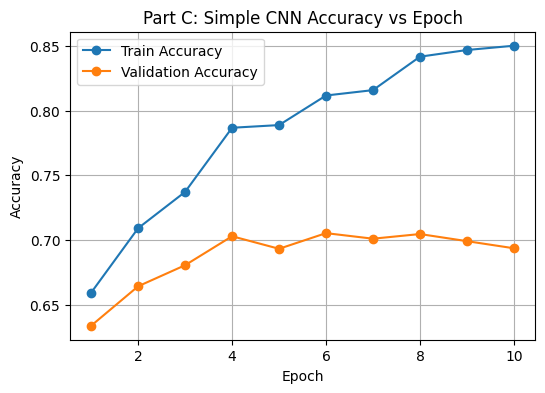

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(df_c["Epoch"], df_c["Train Accuracy"], marker='o', label="Train Accuracy")
plt.plot(df_c["Epoch"], df_c["Validation Accuracy"], marker='o', label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Part C: Simple CNN Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
df_c.to_csv("df_c.csv", index=False)

In [11]:
import matplotlib.pyplot as plt

def save_table_as_image(df, filename, title):
    fig, ax = plt.subplots(figsize=(6, 1 + 0.4*len(df)))
    ax.axis('off')
    ax.set_title(title)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc='center',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.3)

    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.close(fig)

save_table_as_image(df_c, "PartC_Table.png", "Part C Accuracy Table")
